# Setup

In [ ]:
from IPython.display import display, HTML
display(HTML(
"""
<a target="_blank" href="https://colab.research.google.com/github/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
"""
))

In [ ]:
using_colab = True

In [ ]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

    !mkdir images
    !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg

    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

PyTorch version: 2.5.0+cu121
Torchvision version: 0.20.0+cu121
CUDA is available: True
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-wai4tdz_
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-wai4tdz_
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
mkdir: cannot create directory ‘images’: File exists
--2024-10-30 01:07:00--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99846 (98K) [image/jpeg]
Saving to: ‘images/dog.jpg.1’

dog

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
from google.colab import files
from PIL import Image
import io

# Functions

In [ ]:
# reads the output from SamAutomaticMaskGenerator.generate() method and plots image with represented masks

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4)) # creates mask
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation'] # extracts the binary segmentation mask for the current annotation
        color_mask = np.concatenate([np.random.random(3), [0.35]]) # generates a random semi-transparent color for the mask
        img[m] = color_mask # applies the color mask to the corresponding pixels in the image, where the segmentation mask is True
    ax.imshow(img)

In [ ]:
# pre-processes images to not exceed 100 KB of size

def preprocess_image(file_path, max_file_size_kb=100, step=10, quality=85):
    """
    Resize and compress the image to meet the file size requirement and return the image as a NumPy array for use with SamAutomaticMaskGenerator.

    Args:
    file_path (str): Path to the input image file.
    max_file_size_kb (int): Maximum file size in kilobytes.
    step (int): Decrease in size percentage with each iteration.
    quality (int): Compression quality.

    Returns:
    np.ndarray: Processed image as a NumPy array.
    """
    # Load the image
    img = Image.open(file_path)
    if img.mode == 'P':  # Check if the image is in 'P' mode
        img = img.convert('RGB')  # Convert to 'RGB'

    img_format = 'JPEG'  # Set format to JPEG for all images

    # Continuously adjust the image until it meets the size requirement
    while True:
        # Convert image to byte array to check size
        img_byte_arr = io.BytesIO()
        img.save(img_byte_arr, format=img_format, quality=quality)
        size_kb = len(img_byte_arr.getvalue()) / 1024

        # If size is acceptable, convert to NumPy array and return
        if size_kb <= max_file_size_kb:
            img_byte_arr.seek(0)  # Rewind the file pointer to the start
            img_final = Image.open(img_byte_arr)
            return np.array(img_final)

        # Reduce dimensions and quality for the next iteration
        new_width = int(img.width * ((100 - step) / 100))
        new_height = int(img.height * ((100 - step) / 100))
        img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
        quality = max(10, quality - 5)  # Avoid quality less than 10

In [ ]:
def section_detector(image: np.array) -> np.array:
    """Generate instance segmentation of an optical image of a wafer.

    Args:
        image (np.array): Optical image of wafer of shape (H, W).

    Returns:
        np.array: Instance segmentation of shape (H,W) where value of 0 means background, and nonzero values indicate the instance ID of the section.
    """
    # Add segmentation code here
    segmentation = np.zeros(image.shape, dtype=np.uint16)

    return segmentation

# Implementation

Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. A mask represents an object that was identified. These keys are:
* `segmentation` : the mask
* `area` : the area of the mask in pixels
* `bbox` : the boundary box of the mask in XYWH format
* `predicted_iou` : the model's own prediction for the quality of the mask
* `point_coords` : the sampled input point that generated this mask
* `stability_score` : an additional measure of mask quality
* `crop_box` : the crop of the image used to generate this mask in XYWH format

Saving wafer4_250nm_100sections_0.08mm-s_RGB (2)-min.png to wafer4_250nm_100sections_0.08mm-s_RGB (2)-min (1).png


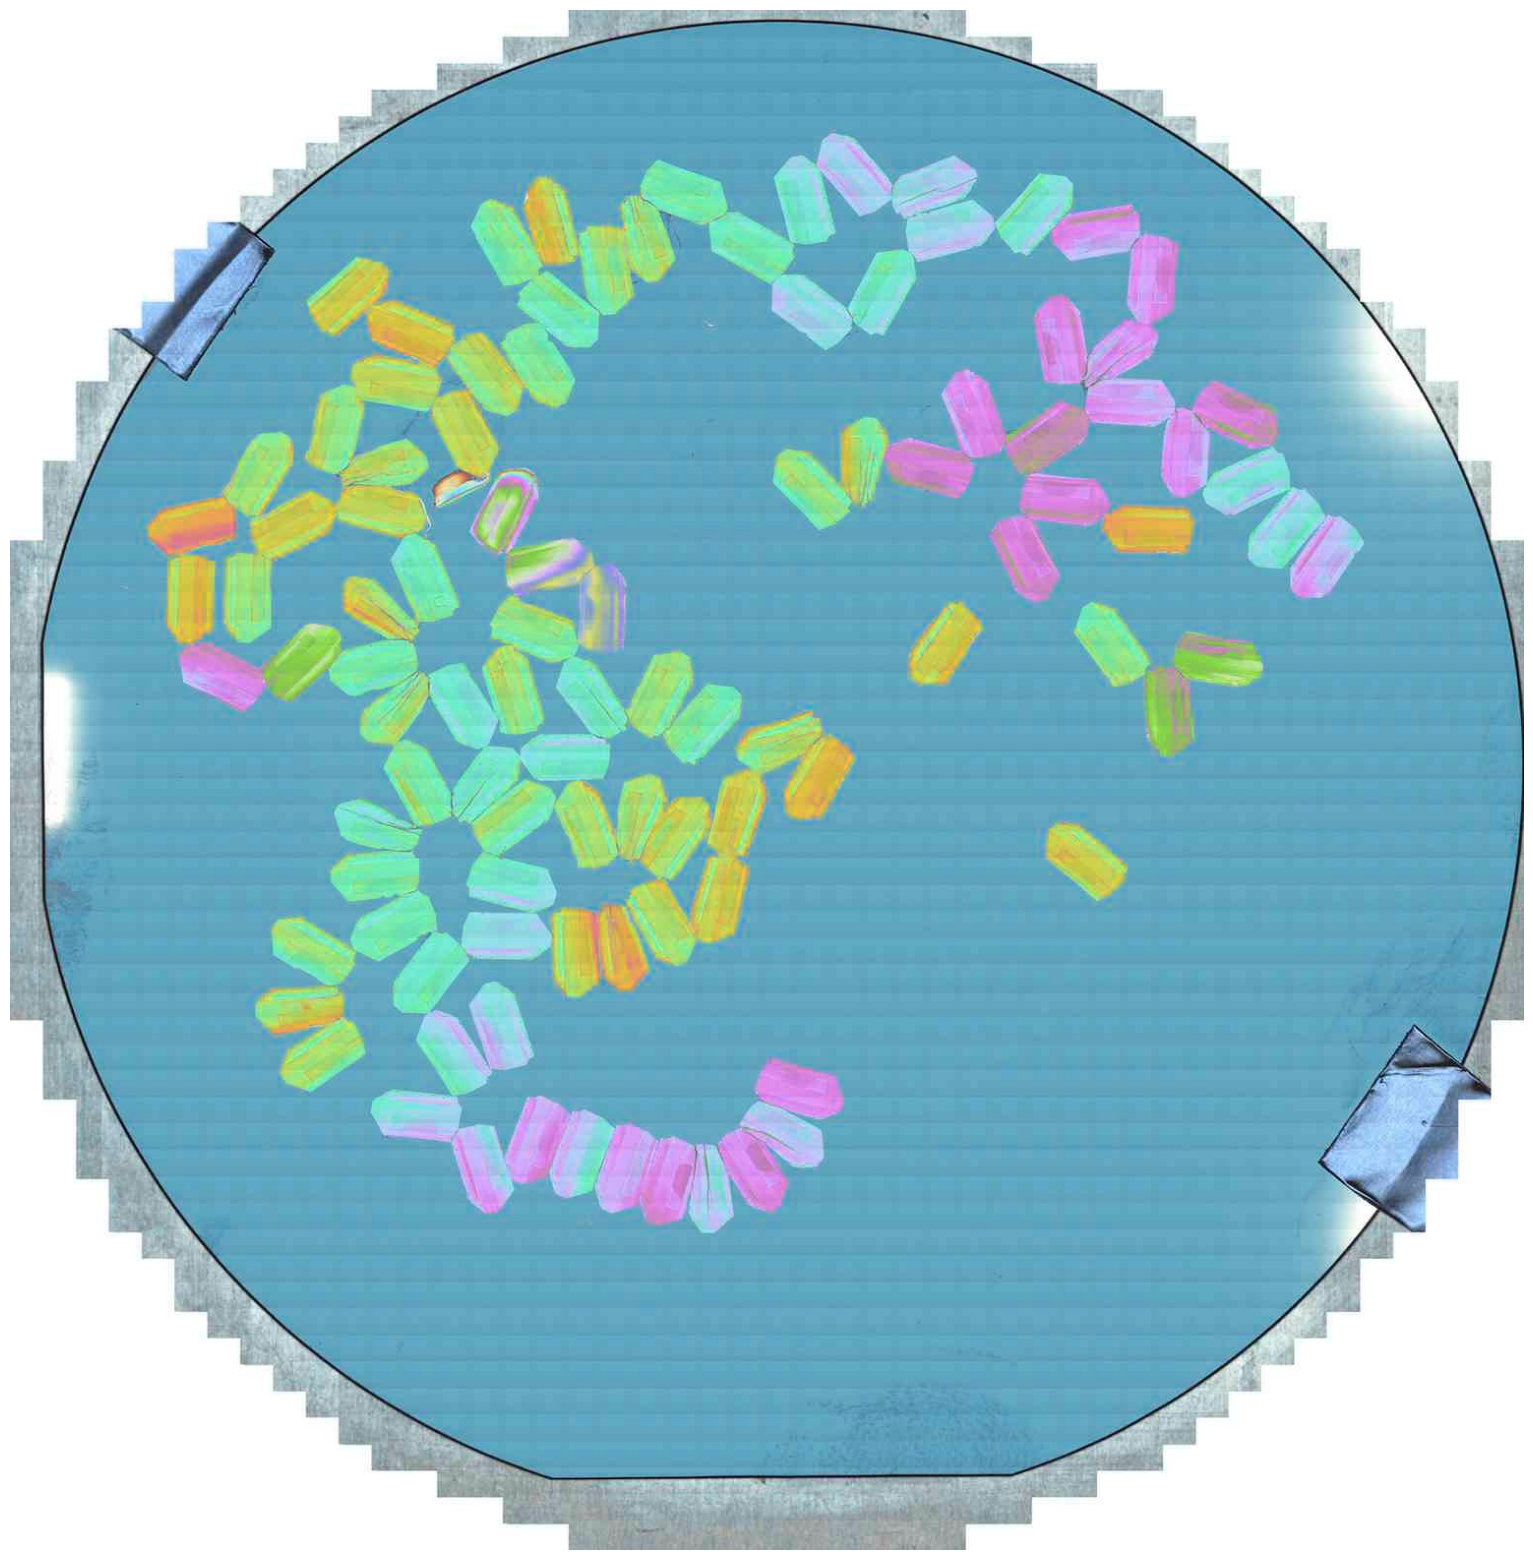

In [ ]:
# upload, compress, and display image

uploaded = files.upload()
filename = next(iter(uploaded))
image = preprocess_image(filename) # compressing the image
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Plotting
plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
# setting up model

import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth" # Specifies the path to the pre-trained SAM model checkpoint file
model_type = "vit_h" # Specifies the architecture of the SAM model

device = "cuda" # Sets the device to use for inference, in this case, "cuda" (GPU)

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

#mask_generator = SamAutomaticMaskGenerator(sam)

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,  # Requires open-cv to run post-processing
)

# run identification model

masks = mask_generator.generate(image)

/usr/local/lib/python3.10/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


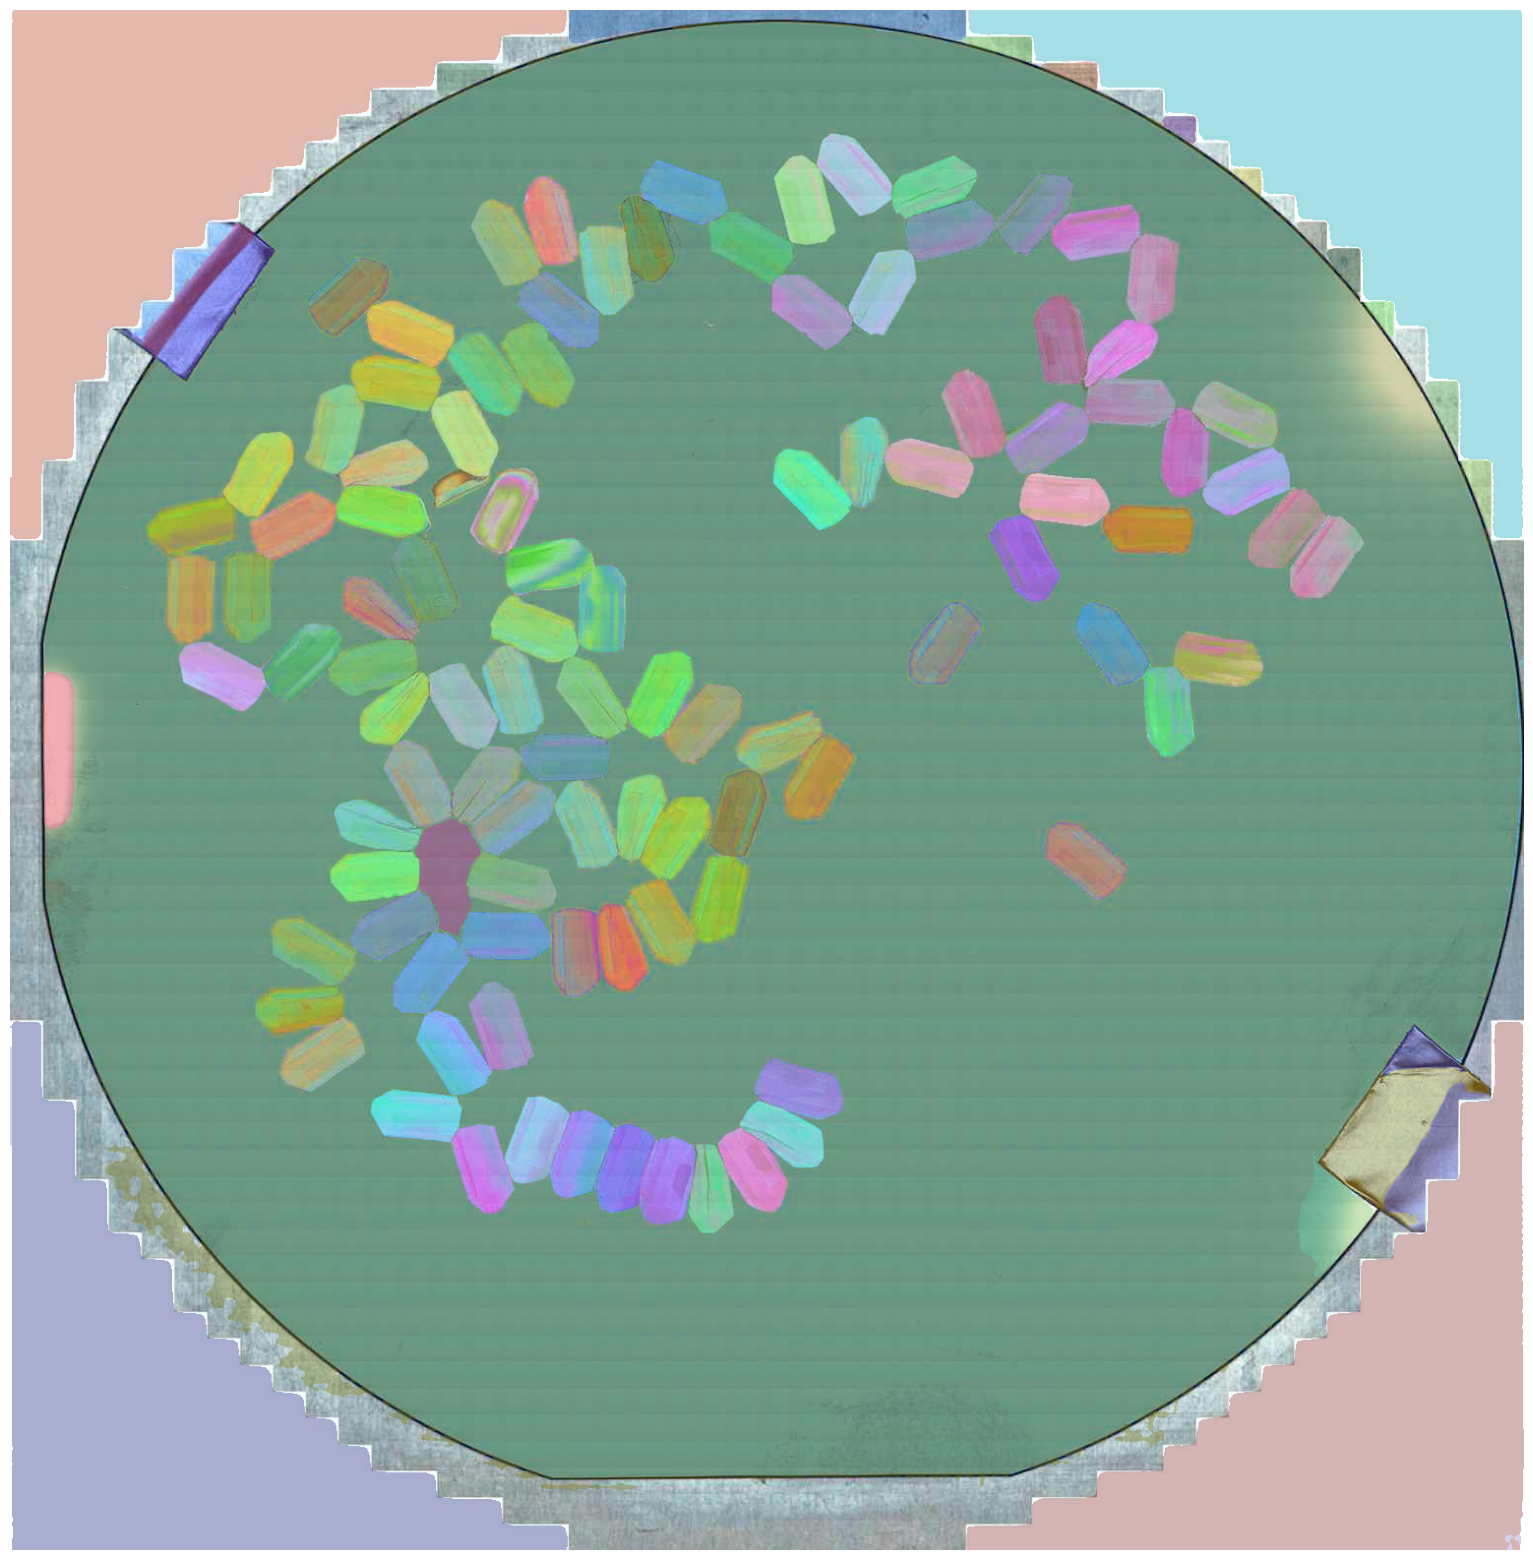

144


In [ ]:
# Plotting results

plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()
print(len(masks))